In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

import torch
torch.set_num_threads(2)
torch.set_num_interop_threads(2)
torch.cuda.set_device(3)
print(f"Using GPU: {torch.cuda.current_device()} "
      f"({torch.cuda.get_device_name(3)})")

Using GPU: 3 (Quadro RTX 6000)


In [2]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
%matplotlib notebook
from argparse import ArgumentParser
import yaml
import os
import math
import torch
# from torch import vmap
from torch.func import vmap, grad
from models import FNN2d
from train_utils import Adam

from solver.BlackScholesEq import BlackScholesEq1D
import traceback

import scipy.io
import torch.nn.functional as F
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import numpy as np
import imageio


from tqdm import tqdm
from train_utils.utils import save_checkpoint, load_checkpoint, update_config, load_config
from train_utils.losses import LpLoss
import train_utils.datasets as datasets
from importlib import reload
reload(datasets)
from train_utils.datasets import DataLoaderBS

try:
    import wandb
except ImportError:
    wandb = None


# Solver Sanity Check

Verify the reference Crank–Nicolson solver before generating training data. We march backward in **τ = T − t** from the terminal payoff (τ = 0) to today's price (τ = T).

device: cuda
solution shape: (51, 256)   # (n_snapshots, Nx)
first tau: 0.0000, last tau: 1.0000


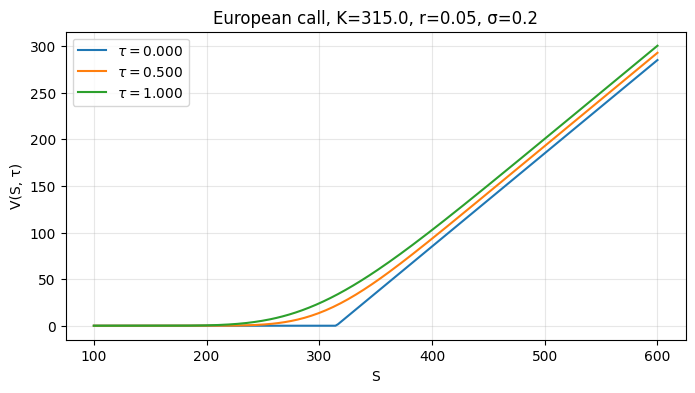

relative L2 error vs analytical BS at τ=T: 8.6588e-06


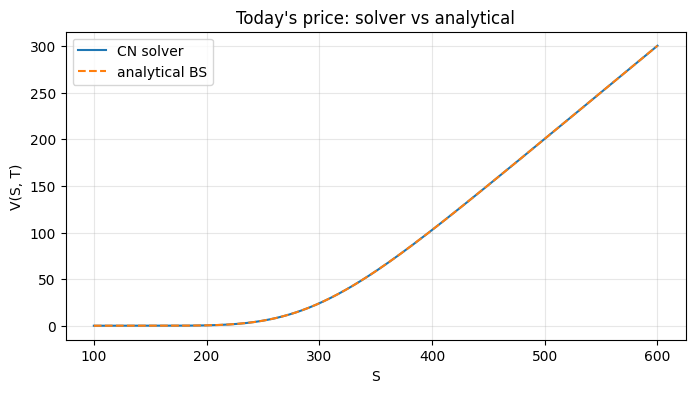

In [3]:
%matplotlib inline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Problem parameters
K = 315.0          # representative AAPL strike
r = 0.05           # risk-free rate
sigma = 0.2        # volatility
T = 1.0            # time to maturity
S_min, S_max = 100.0, 600.0
Nx = 256
dtau = 1e-3

bs = BlackScholesEq1D(
    S_min=S_min, S_max=S_max, Nx=Nx,
    r=r, sigma=sigma, dtau=dtau, T=T,
    device=device,
)

# Terminal payoff is the initial condition in tau coordinates
v0 = bs.call_payoff(K)
bc_lo, bc_hi = bs.call_bcs(K)

# Save ~50 snapshots over [0, T]
save_interval = max(1, int(T / dtau / 50))
V = bs.bs_driver(v0, bc_lo, bc_hi, save_interval=save_interval)

S = bs.S_grid.detach().cpu()
tau_list = bs.T_list

print(f'device: {device}')
print(f'solution shape: {tuple(V.shape)}   # (n_snapshots, Nx)')
print(f'first tau: {tau_list[0]:.4f}, last tau: {tau_list[-1]:.4f}')

# Plot a few tau slices
fig, ax = plt.subplots(figsize=(8, 4))
for idx in [0, len(V) // 2, -1]:
    ax.plot(S, V[idx].detach().cpu(), label=fr'$\tau={tau_list[idx]:.3f}$')
ax.set_xlabel('S')
ax.set_ylabel('V(S, τ)')
ax.set_title(f'European call, K={K}, r={r}, σ={sigma}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Optional: compare final slice to closed-form Black–Scholes at t=0
def bs_call_price(S, K, r, sigma, T_rem):
    """Analytical European call; T_rem = time to maturity."""
    S = torch.as_tensor(S, dtype=torch.float64)
    if T_rem <= 0:
        return torch.clamp(S - K, min=0.0)
    d1 = (torch.log(S / K) + (r + 0.5 * sigma**2) * T_rem) / (sigma * math.sqrt(T_rem))
    d2 = d1 - sigma * math.sqrt(T_rem)
    from torch.special import ndtr
    return S * ndtr(d1) - K * math.exp(-r * T_rem) * ndtr(d2)

V_final = V[-1].detach().cpu()
V_exact = bs_call_price(S, K, r, sigma, T).cpu()
rel_err = torch.norm(V_final - V_exact) / torch.norm(V_exact)
print(f'relative L2 error vs analytical BS at τ=T: {rel_err.item():.4e}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(S, V_final, label='CN solver')
ax.plot(S, V_exact, '--', label='analytical BS')
ax.set_xlabel('S')
ax.set_ylabel('V(S, T)')
ax.set_title('Today\'s price: solver vs analytical')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Define Loss Functions

## Finite Difference Residual

In [4]:
def FDM_BlackScholes(u, D=1.0, r=0.05, sigma=0.2, T=1.0, S_min=1.0, S_max=200.0):
    """
    Black-Scholes PDE residual on a normalized (tau_norm, x_norm) grid.

    PDE in log-price x=log(S) and tau=T-t:
        V_tau = a*V_xx + b*V_x - r*V,  a=0.5*sigma^2, b=r-0.5*sigma^2

    DataLoader coordinates: tau_norm in [0,1] -> [0,T], x_norm in [0,1] -> log(S) in [log(S_min), log(S_max)].
    Coefficients are scaled accordingly.

    u : [batch, Ntau, Nx]
    Returns residual of shape [batch, Ntau-2, Nx-2].
    """
    batchsize = u.size(0)
    nt = u.size(1)
    nx = u.size(2)
    u = u.reshape(batchsize, nt, nx)

    dt = D / (nt - 1)   # normalized tau spacing
    dx = D / (nx - 1)   # normalized log-S spacing

    Lx    = math.log(S_max / S_min)
    a     = 0.5 * sigma ** 2
    b     = r - 0.5 * sigma ** 2
    a_eff = a * T / Lx ** 2
    b_eff = b * T / Lx
    r_eff = r * T

    ux  = (u[:, :, 2:] - u[:, :, :-2])                        / (2.0 * dx)
    uxx = (u[:, :, 2:] - 2.0 * u[:, :, 1:-1] + u[:, :, :-2]) / dx ** 2
    utau = (u[:, 2:, :] - u[:, :-2, :]) / (2.0 * dt)

    Du = (utau[:, :, 1:-1]
          - a_eff * uxx[:, 1:-1, :]
          - b_eff * ux[:, 1:-1, :]
          + r_eff * u[:, 1:-1, 1:-1])
    return Du


def PINO_loss_bs(u, u0, r=0.05, sigma=0.2, T=1.0, S_min=1.0, S_max=200.0):
    """
    PINO loss: IC matching + Black-Scholes PDE residual.

    u  : [batch, Ntau, Nx]  full solution predicted by model
    u0 : [batch, Nx]        payoff (initial condition at tau=0)
    """
    batchsize = u.size(0)
    nt = u.size(1)
    nx = u.size(2)
    u = u.reshape(batchsize, nt, nx)

    loss_u = F.mse_loss(u[:, 0, :], u0)

    Du = FDM_BlackScholes(u, r=r, sigma=sigma, T=T, S_min=S_min, S_max=S_max)
    loss_f = F.mse_loss(Du, torch.zeros_like(Du))

    return loss_u, loss_f

# Define Training Function

In [5]:
def train_bs(model,
             train_loader,
             optimizer,
             scheduler,
             config,
             rank=0,
             log=False,
             project='PINO-BlackScholes-default',
             group='default',
             tags=['default'],
             use_tqdm=True):
    if rank == 0 and wandb and log:
        run = wandb.init(project=project,
                         entity='shawngr2',
                         group=group,
                         config=config,
                         tags=tags, reinit=True,
                         settings=wandb.Settings(start_method='fork'))

    data_weight = config['train']['xy_loss']
    f_weight    = config['train']['f_loss']
    ic_weight   = config['train']['ic_loss']
    r     = config['data']['r']
    sigma = config['data']['sigma']
    T     = config['data']['T']
    S_min = config['data']['S_min']
    S_max = config['data']['S_max']
    ckpt_freq = config['train']['ckpt_freq']

    model.train()
    myloss = LpLoss(size_average=True)
    pbar = range(config['train']['epochs'])
    if use_tqdm:
        pbar = tqdm(pbar, dynamic_ncols=True, smoothing=0.1)

    for e in pbar:
        model.train()
        train_pino = 0.0
        data_l2    = 0.0
        train_ic   = 0.0
        train_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(rank), y.to(rank)
            out = model(x).reshape(y.shape)
            data_loss = myloss(out, y)

            loss_ic, loss_f = PINO_loss_bs(
                out, x[:, 0, :, 0],
                r=r, sigma=sigma, T=T, S_min=S_min, S_max=S_max)
            total_loss = loss_ic * ic_weight + loss_f * f_weight + data_loss * data_weight

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            data_l2    += data_loss.item()
            train_pino += loss_f.item()
            train_loss += total_loss.item()
            train_ic   += loss_ic.item()

        scheduler.step()
        data_l2    /= len(train_loader)
        train_pino /= len(train_loader)
        train_loss /= len(train_loader)
        train_ic   /= len(train_loader)

        if use_tqdm:
            pbar.set_description(
                f'Epoch {e}, train loss: {train_loss:.5f} '
                f'train f error: {train_pino:.5f}; '
                f'data l2 error: {data_l2:.5f}; '
                f'train ic error: {train_ic:.5f}'
            )
        if wandb and log:
            wandb.log({
                'Train f error':  train_pino,
                'Train L2 error': data_l2,
                'Train ic error': train_ic,
                'Train loss':     train_loss,
            })

        if e % ckpt_freq == 0:
            save_checkpoint(config['train']['save_dir'],
                            config['train']['save_name'].replace('.pt', f'_{e}.pt'),
                            model, optimizer)

    save_checkpoint(config['train']['save_dir'],
                    config['train']['save_name'],
                    model, optimizer)
    print('Done!')

# Evaluation Function

In [6]:
def eval_bs(model,
            dataloader,
            config,
            device,
            use_tqdm=True):
    model.eval()
    myloss = LpLoss(size_average=True)
    r     = config['data']['r']
    sigma = config['data']['sigma']
    T     = config['data']['T']
    S_min = config['data']['S_min']
    S_max = config['data']['S_max']

    pbar = tqdm(dataloader, dynamic_ncols=True, smoothing=0.05) if use_tqdm else dataloader

    test_err = []
    f_err    = []

    with torch.no_grad():
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            out = model(x).reshape(y.shape)
            data_loss = myloss(out, y)

            _, f_loss = PINO_loss_bs(
                out, x[:, 0, :, 0],
                r=r, sigma=sigma, T=T, S_min=S_min, S_max=S_max)
            test_err.append(data_loss.item())
            f_err.append(f_loss.item())

    mean_f_err = np.mean(f_err)
    std_f_err  = np.std(f_err, ddof=1) / np.sqrt(len(f_err))
    mean_err   = np.mean(test_err)
    std_err    = np.std(test_err, ddof=1) / np.sqrt(len(test_err))

    print(f'==Averaged relative L2 error mean: {mean_err}, std error: {std_err}==\n'
          f'==Averaged equation error mean: {mean_f_err}, std error: {std_f_err}==')

# Save and Load Data

In [7]:
def save_data(data_path, test_x, test_y, preds_y):
    data_dir, _ = os.path.split(data_path)
    os.makedirs(data_dir, exist_ok=True)
    np.savez(data_path, test_x=test_x, test_y=test_y, preds_y=preds_y)

def load_data(data_path):
    data = np.load(data_path)
    return data['test_x'], data['test_y'], data['preds_y']

# Visualization

In [8]:
def plot_predictions(key, test_x, test_y, preds_y,
                     S_min=1.0, S_max=200.0,
                     save_path=None, font_size=None):
    if font_size is not None:
        plt.rcParams.update({'font.size': font_size})

    pred = preds_y[key]
    true = test_y[key]
    a    = test_x[key]

    Ntau, Nx, _ = a.shape
    payoff  = a[0, :, 0]
    x_norm  = a[0, :, 1]
    tau_norm = a[:, 0, 2]

    Lx = math.log(S_max / S_min)
    S  = np.exp(np.log(S_min) + x_norm * Lx)

    slice_indices = sorted({0, Ntau // 2, Ntau - 1})
    slice_labels = [f'$tau={tau_norm[i]:.3f}$' for i in slice_indices]

    fig = plt.figure(figsize=(23, 5))

    plt.subplot(1, 4, 1)
    plt.plot(S, payoff)
    plt.xlabel('$S$')
    plt.ylabel('$V$')
    plt.title('Payoff $V(S, tau=0)$')
    plt.xlim([S_min, S_max])
    plt.tight_layout()

    def plot_line_panel(values, title, ylabel):
        for idx, label in zip(slice_indices, slice_labels):
            plt.plot(S, values[idx], label=label)
        plt.xlabel('$S$')
        plt.ylabel(ylabel)
        plt.title(title)
        plt.xlim([S_min, S_max])
        plt.grid(alpha=0.25)
        plt.legend(fontsize=8)
        plt.tight_layout()

    plt.subplot(1, 4, 2)
    plot_line_panel(true, 'Exact $V(S, tau)$', '$V$')

    plt.subplot(1, 4, 3)
    plot_line_panel(pred, 'Predict $V(S, tau)$', '$V$')

    plt.subplot(1, 4, 4)
    plot_line_panel(pred - true, 'Absolute Error', 'Error')

    if save_path is not None:
        if save_path.endswith((os.sep, '/', '\\')) or os.path.isdir(save_path):
            os.makedirs(save_path, exist_ok=True)
            save_file = os.path.join(save_path, f'plot_predictions_{key}.png')
        else:
            os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
            save_file = save_path if save_path.lower().endswith('.png') else f'{save_path}.png'
        plt.savefig(save_file, bbox_inches='tight')
    # plt.show()

# Movies

In [9]:
def generate_movie_1D(key, test_x, test_y, preds_y,
                      S_min=1.0, S_max=200.0,
                      plot_title='Black-Scholes',
                      movie_dir='', movie_name='movie.gif',
                      frame_basename='movie', frame_ext='jpg',
                      remove_frames=True, font_size=None):
    frame_files = []
    os.makedirs(movie_dir, exist_ok=True)
    if font_size is not None:
        plt.rcParams.update({'font.size': font_size})

    pred = preds_y[key]
    true = test_y[key]
    a    = test_x[key]

    Ntau, Nx, _ = a.shape
    x_norm   = a[0, :, 1]
    tau_norm = a[:, 0, 2]
    Lx = math.log(S_max / S_min)
    S  = np.exp(np.log(S_min) + x_norm * Lx)

    fig = plt.figure(figsize=(6, 5))
    ax  = fig.add_subplot(111)
    plt.ion()
    fig.show()
    fig.canvas.draw()

    ax.plot(S, true[0], 'b-',  label='Exact')
    ax.plot(S, pred[0], 'r--', label='PINO Prediction')
    ylim = plt.ylim()
    plt.tight_layout()

    for i in range(Ntau):
        ax.clear()
        ax.plot(S, true[i], 'b-',  label='Exact')
        ax.plot(S, pred[i], 'r--', label='PINO Prediction')
        plt.xlabel('$S$')
        plt.ylabel('$V$')
        plt.title(f'{plot_title}  tau={tau_norm[i]:.2f}')
        plt.legend(loc='upper left')
        plt.ylim(ylim)
        plt.xlim([S_min, S_max])
        plt.tight_layout()
        fig.canvas.draw()

        if movie_dir:
            frame_path = os.path.join(movie_dir, f'{frame_basename}-{i:03}.{frame_ext}')
            frame_files.append(frame_path)
            plt.savefig(frame_path)

    if movie_dir:
        movie_path = os.path.join(movie_dir, movie_name)
        with imageio.get_writer(movie_path, mode='I') as writer:
            for frame in frame_files:
                writer.append_data(imageio.imread(frame))

    if movie_dir and remove_frames:
        for frame in frame_files:
            try:
                os.remove(frame)
            except Exception:
                pass

# Load Config File

In [10]:
config_file = 'configs/custom/black_scholes-0000.yaml'
config = load_config(config_file)
display(config)

{'data': {'name': 'BlackScholes-0000',
  'total_num': 1000,
  'n_train': 900,
  'n_test': 100,
  'nx': 512,
  'nt': 100,
  'sub': 4,
  'sub_t': 4,
  'r': 0.05,
  'sigma': 0.2,
  'T': 1.0,
  'S_min': 100.0,
  'S_max': 600.0,
  'K_min': 200.0,
  'K_max': 500.0},
 'model': {'layers': [16, 24, 24, 32, 32],
  'modes1': [15, 12, 9, 9],
  'modes2': [15, 12, 9, 9],
  'fc_dim': 128,
  'activation': 'gelu'},
 'train': {'batchsize': 20,
  'epochs': 500,
  'milestones': [150, 300, 450],
  'base_lr': 0.001,
  'scheduler_gamma': 0.5,
  'ic_loss': 5.0,
  'f_loss': 1.0,
  'xy_loss': 10.0,
  'save_dir': 'BlackScholes',
  'save_name': 'BlackScholes-eqn.pt',
  'ckpt': 'checkpoints/BlackScholes/BlackScholes-eqn.pt',
  'ckpt_freq': 100},
 'log': {'project': 'PINO-BlackScholes', 'group': 'BlackScholes-0000'},
 'test': {'batchsize': 1,
  'ckpt': 'checkpoints/BlackScholes/BlackScholes-eqn.pt'}}

# Parameters

In [11]:
Nsamples = config['data']['total_num']
N        = config['data']['nx']
Nt0      = config['data']['nt']
sub_x    = config['data']['sub']
sub_t    = config['data']['sub_t']
Nx       = N // sub_x
Nt       = Nt0 // sub_t + 1

r     = config['data']['r']
sigma = config['data']['sigma']
T     = config['data']['T']
S_min = config['data']['S_min']
S_max = config['data']['S_max']
K_min = config['data']['K_min']
K_max = config['data']['K_max']

# Solver step size and snapshot interval
dtau_solve  = 1e-3                           # fine CN step for accuracy
steps_total = int(T / dtau_solve)            # e.g. 1000
save_int    = max(1, steps_total // Nt0)     # e.g. 10 -> 101 snapshots

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
print(f'Nx={Nx}, Nt={Nt}, save_int={save_int}')

device: cuda
Nx=128, Nt=26, save_int=10


# Generate Dataset

Sample `Nsamples` strike prices K uniformly from [K_min, K_max],
compute the European call payoff for each K, and run the Crank-Nicolson solver.

In [12]:
import torch

bs_solver = BlackScholesEq1D(
    S_min=S_min, S_max=S_max, Nx=N,
    r=r, sigma=sigma, dtau=dtau_solve, T=T,
    device=device,
)

# 1. Initialize solver setup parameters
Nsamples = 1000
K_samples = torch.linspace(K_min, K_max, Nsamples, device=device, dtype=torch.float64)

# 2. Get grids and configurations out of the solver instance
S_grid = bs_solver.S_grid       # Shape: [Nx]
Nx = bs_solver.Nx
dtau = bs_solver.dtau
tend = bs_solver.tend
r = bs_solver.r

# ------------------------------------------------------------------
# STEP 1: Fully Batched Payoffs & Initial Conditions
# S_grid is [Nx], K_samples is [Nsamples]. We unsqueeze to broadcast:
# [1, Nx] - [Nsamples, 1] -> [Nsamples, Nx]
# ------------------------------------------------------------------
print("Generating batched initial payoff states...")
a_gpu = torch.clamp(S_grid.unsqueeze(0) - K_samples.unsqueeze(1), min=0.0)

# ------------------------------------------------------------------
# STEP 2: Precompute Batched Boundary Curves for all time steps
# ------------------------------------------------------------------
print("Precomputing batched boundary arrays...")
# Determine every individual tau step matching the loop structure
tau_steps = []
current_tau = 0.0
while current_tau < tend - 1e-12:
    tau_steps.append(current_tau)
    current_tau += dtau
tau_steps = torch.tensor(tau_steps, device=device, dtype=torch.float64)
N_time_steps = len(tau_steps)

# Precalculate upper boundary condition values for all samples over all time:
# Shape: [Nsamples, N_time_steps]
S_hi = S_grid[-1]
# Using tensor broadcasting for K_samples [Nsamples, 1] * exp(-r * tau) [1, N_time_steps]
V_hi_all = S_hi - K_samples.unsqueeze(1) * torch.exp(-r * tau_steps.unsqueeze(0))

# ------------------------------------------------------------------
# STEP 3: Optimized Batched Thomas Algorithm
# ------------------------------------------------------------------
def batched_thomas_solve(a_sub, a_diag, a_super, d):
    """
    Solves a tridiagonal system Ax = d simultaneously across a batch.
    d shape: [Nsamples, n]
    """
    n = d.shape[1]
    batch_size = d.shape[0]
    
    c_p = torch.empty(n - 1, device=d.device, dtype=d.dtype)
    d_p = torch.empty(batch_size, n, device=d.device, dtype=d.dtype)

    c_p[0] = a_super[0] / a_diag[0]
    d_p[:, 0] = d[:, 0] / a_diag[0]
    
    for i in range(1, n):
        denom = a_diag[i] - a_sub[i - 1] * c_p[i - 1]
        if i < n - 1:
            c_p[i] = a_super[i] / denom
        d_p[:, i] = (d[:, i] - a_sub[i - 1] * d_p[:, i - 1]) / denom

    x = torch.empty(batch_size, n, device=d.device, dtype=d.dtype)
    x[:, -1] = d_p[:, -1]
    for i in range(n - 2, -1, -1):
        x[:, i] = d_p[:, i] - c_p[i] * x[:, i + 1]
    return x

# ------------------------------------------------------------------
# STEP 4: Batched Solution Time-Marching Loop
# ------------------------------------------------------------------
print("Running parallelized Crank-Nicolson execution over all samples...")
v_current = a_gpu.clone() # Matrix shape: [Nsamples, Nx]

# Explicit endpoints enforcement
v_current[:, 0] = 0.0
v_current[:, -1] = S_hi - K_samples

V_history = []
save_interval = save_int
step_idx = 0

if save_interval != 0 and step_idx % save_interval == 0:
    V_history.append(v_current.clone())

# Interior configuration parameters
alpha = bs_solver.alpha
gamma = bs_solver.gamma
B_matrix = bs_solver.B # Matrix shape: [Nx-2, Nx-2]

for step_idx in range(N_time_steps):
    tau_old = tau_steps[step_idx]
    tau_new = tau_old + dtau
    
    # Extract lower boundary parameters (always 0 for European calls)
    v_lo_old = 0.0
    v_lo_new = 0.0
    
    # Extract upper boundary parameters for this specific time slice
    v_hi_old = V_hi_all[:, step_idx]
    if step_idx + 1 < N_time_steps:
        v_hi_new = V_hi_all[:, step_idx + 1]
    else:
        v_hi_new = S_hi - K_samples * math.exp(-r * (tau_new.item()))
        
    # Isolate interior nodes: Shape [Nsamples, Nx - 2]
    v_in = v_current[:, 1:-1]
    
    # Batched matrix multiplication: [Nsamples, Nx-2] @ [Nx-2, Nx-2].T -> [Nsamples, Nx-2]
    rhs = torch.matmul(v_in, B_matrix.t())
    
    # Apply batched Dirichlet boundary adjustments
    rhs[:, 0]  = rhs[:, 0]  + 0.5 * dtau * alpha * (v_lo_old + v_lo_new)
    rhs[:, -1] = rhs[:, -1] + 0.5 * dtau * gamma * (v_hi_old + v_hi_new)
    
    # Solve tridiagonal layout simultaneously across all matrix layers
    v_new_in = batched_thomas_solve(bs_solver.a_sub, bs_solver.a_diag, bs_solver.a_super, rhs)
    
    # Reassemble updated configuration back into full state rows
    v_next = torch.empty_like(v_current)
    v_next[:, 0]    = v_lo_new
    v_next[:, -1]   = v_hi_new
    v_next[:, 1:-1] = v_new_in
    
    v_current = v_next
    
    # Snapshot checking tracker
    loop_step = step_idx + 1
    if save_interval != 0 and loop_step % save_interval == 0:
        V_history.append(v_current.clone())

# ------------------------------------------------------------------
# STEP 5: Reformat Shapes to Match FNO Expected Dataset Dimensions
# ------------------------------------------------------------------
# V_history contains frames of shape [Nsamples, Nx]. 
# Stacking them results in [Ntau_snaps, Nsamples, Nx]
# Permute to transform it to target format: [Nsamples, Ntau_snaps, Nx]
u_gpu = torch.stack(V_history).permute(1, 0, 2)

# Convert arrays back to clean float32 allocations for training steps
a = a_gpu.cpu().float()
u = u_gpu.cpu().float()

print("Generation Complete!")
display(a.shape, u.shape)

Generating batched initial payoff states...
Precomputing batched boundary arrays...
Running parallelized Crank-Nicolson execution over all samples...
Generation Complete!


torch.Size([1000, 512])

torch.Size([1000, 101, 512])

In [13]:
dataset = DataLoaderBS(a, u, config['data']['nx'], config['data']['nt'],
                       config['data']['sub'], config['data']['sub_t'])
train_loader = dataset.make_loader(config['data']['n_train'],
                                   config['train']['batchsize'],
                                   start=0, train=True)
test_loader  = dataset.make_loader(config['data']['n_test'],
                                   config['test']['batchsize'],
                                   start=config['data']['n_train'], train=False)

In [16]:
log = False
model = FNN2d(modes1=config['model']['modes1'],
              modes2=config['model']['modes2'],
              fc_dim=config['model']['fc_dim'],
              layers=config['model']['layers'],
              activation=config['model']['activation']).to(device)

optimizer = Adam(model.parameters(), betas=(0.9, 0.999),
                 lr=config['train']['base_lr'])
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=config['train']['milestones'],
    gamma=config['train']['scheduler_gamma'])

# Load from Checkpoint

In [15]:
load_checkpoint(model, ckpt_path=config['train']['ckpt'], optimizer=None)

Weights loaded from checkpoints/BlackScholes/BlackScholes-eqn.pt


# Train the Model

In [17]:
train_bs(model,
         train_loader,
         optimizer,
         scheduler,
         config,
         rank=device,
         log=log,
         project=config['log']['project'],
         group=config['log']['group'])

Epoch 0, train loss: 19880.06241 train f error: 850.70185; data l2 error: 0.62194; train ic error: 3804.62818:   0%|          | 1/500 [00:00<06:53,  1.21it/s]

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_0.pt


Epoch 100, train loss: 0.78675 train f error: 0.27025; data l2 error: 0.04883; train ic error: 0.00564:  20%|██        | 101/500 [00:50<03:22,  1.97it/s]     

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_100.pt


Epoch 200, train loss: 0.26156 train f error: 0.16472; data l2 error: 0.00770; train ic error: 0.00396:  40%|████      | 201/500 [01:40<02:29,  1.99it/s] 

...

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_300.pt


Epoch 400, train loss: 0.95269 train f error: 0.05907; data l2 error: 0.00559; train ic error: 0.16754:  80%|████████  | 401/500 [03:20<00:49,  1.98it/s]

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_400.pt


Epoch 499, train loss: 0.06521 train f error: 0.02205; data l2 error: 0.00339; train ic error: 0.00184: 100%|██████████| 500/500 [04:10<00:00,  2.00it/s]

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn.pt
Done!


# Evaluate on Test Data

In [18]:
eval_bs(model, test_loader, config, device)

100%|██████████| 100/100 [00:00<00:00, 331.85it/s]

==Averaged relative L2 error mean: 0.03985390467569232, std error: 0.0021352634974639174==
==Averaged equation error mean: 116.65775761082769, std error: 10.61080294261072==


In [19]:
Nx = config['data']['nx'] // config['data']['sub']
Nt = config['data']['nt'] // config['data']['sub_t'] + 1
Ntest = config['data']['n_test']
model.eval()
test_x = np.zeros((Ntest,Nt,Nx,3))
preds_y = np.zeros((Ntest,Nt,Nx))
test_y = np.zeros((Ntest,Nt,Nx))
with torch.no_grad():
    for i, data in enumerate(test_loader):
        data_x, data_y = data
        data_x, data_y = data_x.to(device), data_y.to(device)
        pred_y = model(data_x).reshape(data_y.shape)
        test_x[i] = data_x.cpu().numpy()
        test_y[i] = data_y.cpu().numpy()
        preds_y[i] = pred_y.cpu().numpy()
#     data_loss = myloss(out, y)

In [20]:
key = 0

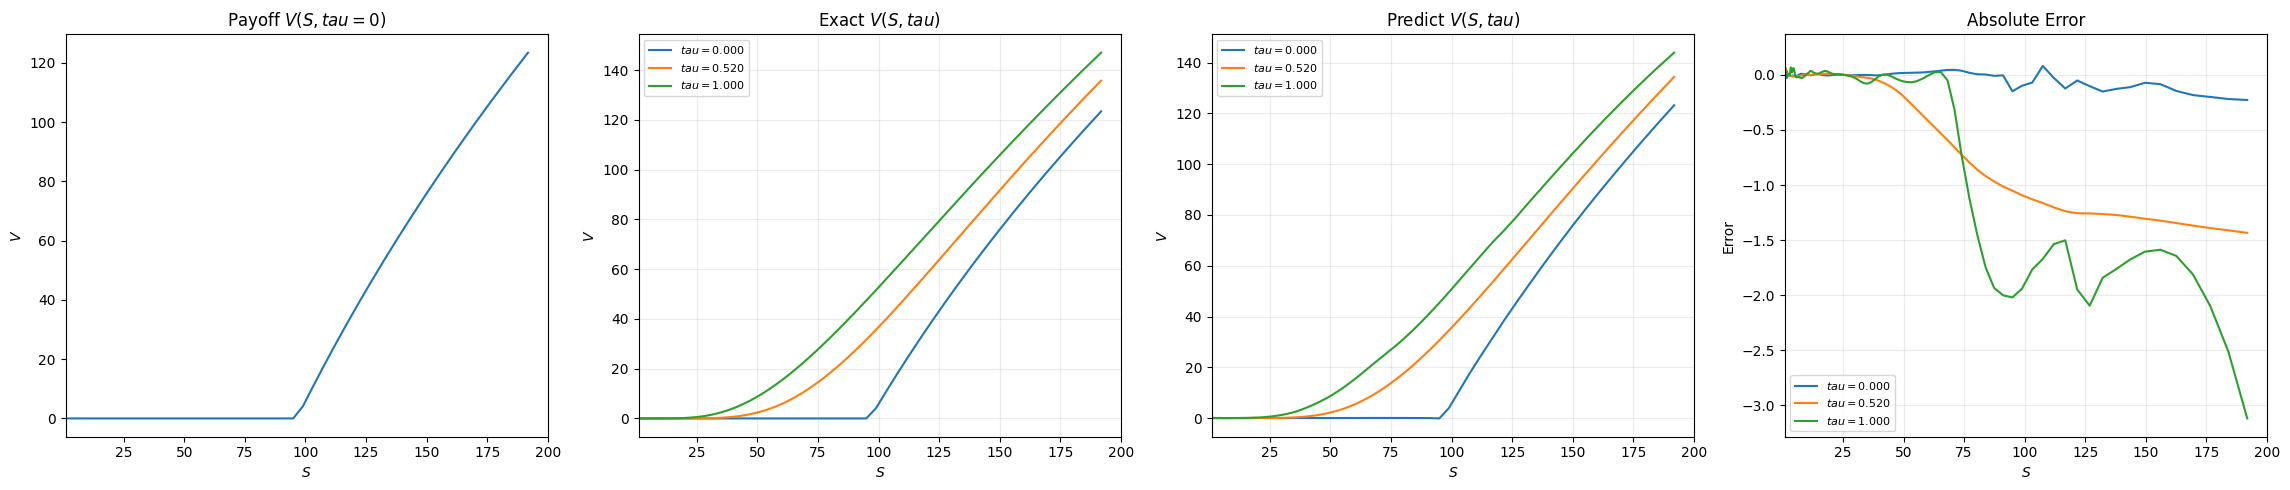

In [21]:
plot_predictions(key, test_x, test_y, preds_y, 1, 200, save_path="BlackScholes/figures/")

/tmp/ipykernel_746114/1195472840.py:55: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(frame))


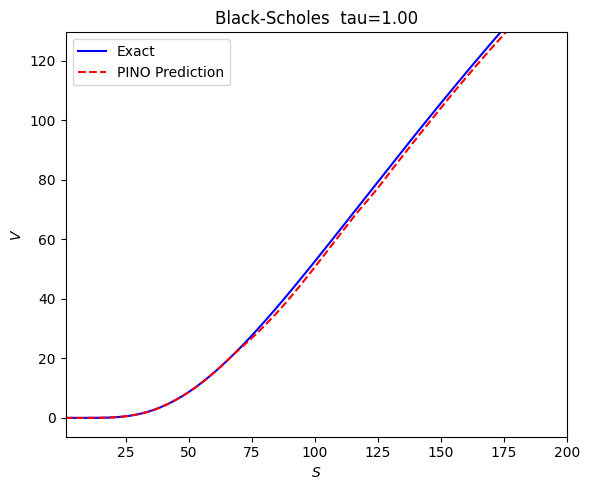

In [22]:
generate_movie_1D(key, test_x, test_y, preds_y,
                      S_min=1.0, S_max=200.0,
                      plot_title='Black-Scholes',
                      movie_dir='BlackScholes/movies/', movie_name='movie.gif',
                      frame_basename='movie', frame_ext='jpg',
                      remove_frames=True, font_size=None)

In [23]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Ensure matplotlib is in inline or agg mode for clean generation
%matplotlib inline

def plot_paper_diagnostic_panel(test_x, test_y, preds_y, S_min=1.0, S_max=200.0, save_path=None):
    """
    Generates a multi-temporal side-by-side diagnostic panel for publication.
    Left: Multi-slice overlay of Exact vs PINO solutions at tau = 0.0, 0.5, 1.0.
          Uses translucent solid tracks and sharp dashed lines to maintain legibility.
    Right: Corresponding Globally Normalized Spatial Error distribution across the grid.
    """
    # Convert tensors to numpy arrays if necessary
    if isinstance(test_x, torch.Tensor): test_x = test_x.cpu().numpy()
    if isinstance(test_y, torch.Tensor): test_y = test_y.cpu().numpy()
    if isinstance(preds_y, torch.Tensor): preds_y = preds_y.cpu().numpy()
    
    # Isolate the first test sample profile (key = 0)
    a = test_x[0]
    true = test_y[0]
    pred = preds_y[0]
    
    # Safely extract coordinate grids matching notebook data structure
    if a.ndim == 3 and a.shape[-1] >= 3:
        x_norm = a[0, :, 1]
        tau_norm = a[:, 0, 2]
        Lx = np.log(S_max / S_min)
        S = np.exp(np.log(S_min) + x_norm * Lx)
    else:
        # Robust fallback if array dimensions differ
        S = np.linspace(S_min, S_max, true.shape[-1])
        tau_norm = np.linspace(0.0, 1.0, true.shape[0])
        
    # Locate indices closest to the requested tau targets (0.0, 0.5, 1.0)
    idx_0 = np.argmin(np.abs(tau_norm - 0.0))
    idx_05 = np.argmin(np.abs(tau_norm - 0.5))
    idx_1 = np.argmin(np.abs(tau_norm - 1.0))
    slice_indices = [idx_0, idx_05, idx_1]
    
    # Professional, high-contrast publication colors for each time slice
    colors = ['#1f77b4', '#2ca02c', '#d62728']  # Blue (tau=0), Green (tau=0.5), Red (tau=1)
    
    # Set up publication-quality figure styles
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.size'] = 11
    plt.rcParams['axes.linewidth'] = 1.2
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # ----------------------------------------------------
    # Left Panel: Multi-Slice Exact vs PINO Overlays (With Halo Visibility)
    # ----------------------------------------------------
    for i, idx in enumerate(slice_indices):
        t_val = tau_norm[idx]
        
        # Exact solution = Thick, semi-translucent solid ribbon
        ax1.plot(S, true[idx], color=colors[i], linestyle='-', linewidth=2.0, alpha=0.45,
                 label=f'Exact ($\\tau = {t_val:.1f}$)')
        
        # PINO prediction = Sharp, thin dashed line centered directly over it
        ax1.plot(S, pred[idx], color=colors[i], linestyle='--', linewidth=1.5, alpha=1.0,
                 label=f'PINO ($\\tau = {t_val:.1f}$)')
                 
    ax1.set_xlabel('Stock Price ($S$)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Option Value ($V$)', fontsize=12, fontweight='bold')
    ax1.set_title('Solution Value Profiles across $\\tau$', fontsize=13, pad=12)
    ax1.set_xlim([S_min, S_max])
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', fontsize=9.5)
    
    # ----------------------------------------------------
    # Right Panel: Combined Globally Scaled Spatial Error
    # ----------------------------------------------------
    max_err = 1e-5  # Floor tracker for dynamic ylim scaling
    for i, idx in enumerate(slice_indices):
        t_val = tau_norm[idx]
        
        # Absolute pointwise error
        abs_error_profile = np.abs(true[idx] - pred[idx])
        
        # Global Relative Scaling per slice: Root-Mean-Square (RMS) profile magnitude
        global_scale = np.sqrt(np.mean(true[idx]**2)) + 1e-8
        normalized_spatial_error = abs_error_profile / global_scale
        
        max_err = max(max_err, np.max(normalized_spatial_error))
        
        ax2.plot(S, normalized_spatial_error, color=colors[i], linewidth=2.0, 
                 label=f'Norm Error ($\\tau = {t_val:.1f}$)')
                 
    ax2.set_xlabel('Stock Price ($S$)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Normalized Error Value', fontsize=12, fontweight='bold')
    ax2.set_title('Spatial Distribution of Globally Scaled Error', fontsize=13, pad=12)
    ax2.set_xlim([S_min, S_max])
    ax2.set_ylim([0.0, max_err * 1.15])  # Dynamic headroom tracking
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', fontsize=9.5)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Publication-ready panel saved successfully to: {save_path}")
        
    plt.show()

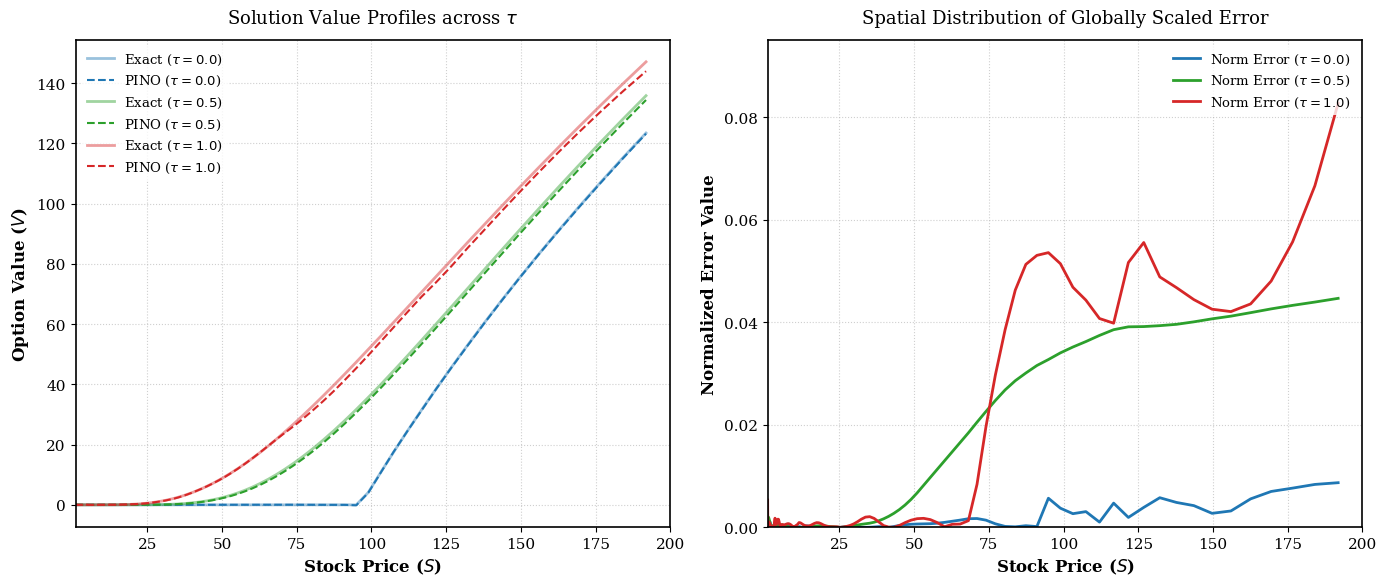

In [24]:
plot_paper_diagnostic_panel(test_x, test_y, preds_y, S_min=1.0, S_max=200.0, save_path=None)

## Comparison of Data Regimes

Comparing the performance of PINO to solve Black-Scholes equation across three data regimes: no data (baseline), clean analytic data, and messy real-world data

In [25]:
# =============================================================================
# Experiment: Data Regime Comparison
# -----------------------------------------------------------------------------
# Three regimes:
#   1. No data       — PDE residual + IC only (no output supervision)
#   2. Synthetic     — full PINO loss with generated CN data   (already trained)
#   3. Real-world    — [partner integration, placeholder below]
#
# After training the no-data model we compare all three against the
# closed-form Black-Scholes analytic solution at a fixed tau slice.
# =============================================================================

# Training function for the no-data (PDE-only) regime
 
def train_bs_nodata(model,
                    train_loader,
                    optimizer,
                    scheduler,
                    config,
                    rank=0,
                    log=False,
                    project='PINO-BlackScholes-nodata',
                    group='nodata',
                    tags=['no-data'],
                    use_tqdm=True):
    """
    PDE-only training: IC matching + Black-Scholes PDE residual.
    Data supervision weight is forced to zero regardless of config.
    """
    if rank == 0 and wandb and log:
        run = wandb.init(project=project,
                         entity='shawngr2',
                         group=group,
                         config=config,
                         tags=tags, reinit=True,
                         settings=wandb.Settings(start_method='fork'))
 
    # Force data weight to zero — PDE + IC only
    data_weight = 0.0
    f_weight    = config['train']['f_loss']
    ic_weight   = config['train']['ic_loss']
 
    r     = config['data']['r']
    sigma = config['data']['sigma']
    T     = config['data']['T']
    S_min = config['data']['S_min']
    S_max = config['data']['S_max']
    ckpt_freq = config['train']['ckpt_freq']
 
    model.train()
    pbar = range(config['train']['epochs'])
    if use_tqdm:
        pbar = tqdm(pbar, dynamic_ncols=True, smoothing=0.1)
 
    for e in pbar:
        model.train()
        train_pino  = 0.0
        train_ic    = 0.0
        train_loss  = 0.0
 
        for x, y in train_loader:
            x, y = x.to(rank), y.to(rank)
            out = model(x).reshape(y.shape)
 
            # No data loss term — IC + PDE only
            loss_ic, loss_f = PINO_loss_bs(
                out, x[:, 0, :, 0],
                r=r, sigma=sigma, T=T, S_min=S_min, S_max=S_max)
            total_loss = loss_ic * ic_weight + loss_f * f_weight
 
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
 
            train_pino  += loss_f.item()
            train_loss  += total_loss.item()
            train_ic    += loss_ic.item()
 
        scheduler.step()
        train_pino  /= len(train_loader)
        train_loss  /= len(train_loader)
        train_ic    /= len(train_loader)
 
        if use_tqdm:
            pbar.set_description(
                f'[NO-DATA] Epoch {e}, loss: {train_loss:.5f} '
                f'f_err: {train_pino:.5f}  ic_err: {train_ic:.5f}'
            )
        if wandb and log:
            wandb.log({
                'Train f error':  train_pino,
                'Train ic error': train_ic,
                'Train loss':     train_loss,
            })
 
        if e % ckpt_freq == 0:
            save_checkpoint(config['train']['save_dir'],
                            config['train']['save_name'].replace('.pt', f'_nodata_{e}.pt'),
                            model, optimizer)
 
    save_checkpoint(config['train']['save_dir'],
                    config['train']['save_name'].replace('.pt', '_nodata.pt'),
                    model, optimizer)
    print('No-data training done!')

In [26]:
# Instantiate and train the no-data model

model_nodata = FNN2d(
    modes1=config['model']['modes1'],
    modes2=config['model']['modes2'],
    fc_dim=config['model']['fc_dim'],
    layers=config['model']['layers'],
    activation=config['model']['activation'],
).to(device)
 
optimizer_nd = Adam(model_nodata.parameters(), betas=(0.9, 0.999),
                    lr=config['train']['base_lr'])
scheduler_nd = torch.optim.lr_scheduler.MultiStepLR(
    optimizer_nd,
    milestones=config['train']['milestones'],
    gamma=config['train']['scheduler_gamma'])
 
train_bs_nodata(model_nodata,
                train_loader,       # same payoff inputs, output labels ignored
                optimizer_nd,
                scheduler_nd,
                config,
                rank=device,
                log=log)

[NO-DATA] Epoch 0, loss: 16272.81734 f_err: 937.12702  ic_err: 3067.13809:   0%|          | 1/500 [00:00<04:20,  1.91it/s]

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_nodata_0.pt


[NO-DATA] Epoch 100, loss: 0.52527 f_err: 0.48023  ic_err: 0.00901:  20%|██        | 101/500 [00:49<03:14,  2.05it/s]     

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_nodata_100.pt


[NO-DATA] Epoch 200, loss: 0.06234 f_err: 0.05525  ic_err: 0.00142:  40%|████      | 201/500 [01:39<02:29,  2.00it/s] 

...

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_nodata_300.pt


[NO-DATA] Epoch 400, loss: 0.02028 f_err: 0.01790  ic_err: 0.00048:  80%|████████  | 401/500 [03:26<01:14,  1.32it/s]

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_nodata_400.pt


[NO-DATA] Epoch 499, loss: 0.00946 f_err: 0.00760  ic_err: 0.00037: 100%|██████████| 500/500 [04:41<00:00,  1.78it/s]

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_nodata.pt
No-data training done!


In [29]:
# Collect predictions from all regimes

def collect_preds(model, loader, device, Ntest, Nt, Nx):
    """Run model over loader, return (test_x, test_y, preds_y) as np arrays."""
    test_x  = np.zeros((Ntest, Nt, Nx, 3))
    test_y  = np.zeros((Ntest, Nt, Nx))
    preds_y = np.zeros((Ntest, Nt, Nx))
    model.eval()
    with torch.no_grad():
        for i, (xb, yb) in enumerate(loader):
            xb, yb = xb.to(device), yb.to(device)
            pred   = model(xb).reshape(yb.shape)
            test_x[i]  = xb.cpu().numpy()
            test_y[i]  = yb.cpu().numpy()
            preds_y[i] = pred.cpu().numpy()
    return test_x, test_y, preds_y
 
Nx_   = config['data']['nx'] // config['data']['sub']
Nt_   = config['data']['nt'] // config['data']['sub_t'] + 1
Ntest = config['data']['n_test']
 
# Synthetic-data model  (already trained above as `model`)
test_x_syn, test_y_syn, preds_syn = collect_preds(
    model, test_loader, device, Ntest, Nt_, Nx_)
 
# No-data model
test_x_nd, test_y_nd, preds_nd = collect_preds(
    model_nodata, test_loader, device, Ntest, Nt_, Nx_)
 
# Real-world model — placeholder; swap in once partner integrates data
# test_x_rw, test_y_rw, preds_rw = collect_preds(
#     model_realworld, test_loader_rw, device, Ntest, Nt_, Nx_)

In [32]:
S[np.argmax(a[0,:,0] > 0)]

IndexError: too many indices for tensor of dimension 2

In [30]:
# Three-way comparison plot at a fixed tau
 
def plot_regime_comparison(test_x_syn, test_y_syn, preds_syn,
                           test_x_nd,  preds_nd,
                           # test_x_rw, preds_rw,   # uncomment when available
                           tau_target=0.5,
                           key=0,
                           S_min=1.0, S_max=200.0,
                           r=0.05, sigma=0.2, T=1.0,
                           save_path=None):
    """
    Side-by-side comparison of three data regimes evaluated at tau = tau_target:
 
      Left  — Solution profiles: Analytic | Synthetic-data PINO | No-data PINO
      Right — Absolute error vs Analytic for Synthetic-data and No-data models
 
    Parameters
    ----------
    test_x_syn  : (Ntest, Nt, Nx, 3)  input array from synthetic-data loader
    test_y_syn  : (Ntest, Nt, Nx)     ground-truth CN labels
    preds_syn   : (Ntest, Nt, Nx)     synthetic-data model predictions
    test_x_nd   : (Ntest, Nt, Nx, 3)  input array from no-data loader (same grid)
    preds_nd    : (Ntest, Nt, Nx)     no-data model predictions
    tau_target  : float               tau slice to visualise (default 0.5)
    key         : int                 which test sample to plot
    """
    import math
 
    # ── Extract coordinates ────────────────────────────────────────────────
    a        = test_x_syn[key]          # (Nt, Nx, 3)
    x_norm   = a[0, :, 1]              # normalised log-S ∈ [0,1]
    tau_norm = a[:, 0, 2]              # normalised tau  ∈ [0,1]
    Lx       = math.log(S_max / S_min)
    S        = np.exp(np.log(S_min) + x_norm * Lx)   # actual stock prices
 
    # Map normalised tau → physical tau then find closest snapshot
    tau_phys = tau_norm * T
    tau_idx  = int(np.argmin(np.abs(tau_phys - tau_target)))
    tau_actual = tau_phys[tau_idx]
 
    # ── Extract slice arrays ───────────────────────────────────────────────
    slice_syn  = preds_syn[key][tau_idx]
    slice_nd   = preds_nd[key][tau_idx]
 
    # Strike K is encoded in the payoff channel (index 0 of channel dim)
    # Recover K from payoff: payoff = max(S - K, 0), so K ≈ S where payoff=0 transitions
    # A cleaner approach: K is stored implicitly; reconstruct from IC channel
    payoff = a[0, :, 0]  # normalised payoff at tau=0
    # Analytic Black-Scholes at tau_actual using bs_call_price defined earlier
    T_rem  = tau_actual   # tau = T - t, so time-to-maturity remaining = tau_actual
    # Reconstruct K: the payoff is clamp(S - K, 0), so find approximate K
    # by finding the first S where payoff > 0
    above  = payoff > 0
    K_est  = S[np.argmax(above)] if above.any() else (S_min + S_max) / 2
 
    analytic = bs_call_price(
        torch.tensor(S, dtype=torch.float64),
        K_est, r, sigma, T_rem
    ).numpy()
 
    # ── Absolute errors relative to analytic ──────────────────────────────
    err_syn = np.abs(slice_syn - analytic)
    err_nd  = np.abs(slice_nd  - analytic)
 
    # ── Plot ───────────────────────────────────────────────────────────────
    plt.rcParams.update({'font.family': 'serif', 'font.size': 11,
                         'axes.linewidth': 1.2})
 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        rf'Data Regime Comparison — Black-Scholes at $\tau = {tau_actual:.3f}$'
        rf'  ($K \approx {K_est:.1f}$, $r={r}$, $\sigma={sigma}$)',
        fontsize=13, y=1.02)
 
    # Left: solution profiles
    ax1.plot(S, analytic,   color='black',    lw=2.0,              label='Analytic')
    ax1.plot(S, slice_syn,  color='tab:blue', lw=1.8, ls='--',    label='PINO (synthetic data)')
    ax1.plot(S, slice_nd,   color='tab:red',  lw=1.8, ls=':',     label='PINO (no data, PDE only)')
    # ax1.plot(S, slice_rw, color='tab:green', lw=1.8, ls='-.',   label='PINO (real-world data)')
 
    ax1.set_xlabel('Stock Price $S$', fontsize=12)
    ax1.set_ylabel('Option Value $V$', fontsize=12)
    ax1.set_title('Solution Profiles', fontsize=12)
    ax1.set_xlim([S_min, S_max])
    ax1.legend(frameon=True, facecolor='white', fontsize=10)
    ax1.grid(True, linestyle=':', alpha=0.5)
 
    # Right: absolute error vs analytic
    ax2.plot(S, err_syn, color='tab:blue', lw=1.8, ls='--', label='Synthetic vs Analytic')
    ax2.plot(S, err_nd,  color='tab:red',  lw=1.8, ls=':',  label='No-data vs Analytic')
    # ax2.plot(S, err_rw, color='tab:green', lw=1.8, ls='-.', label='Real-world vs Analytic')
 
    ax2.set_xlabel('Stock Price $S$', fontsize=12)
    ax2.set_ylabel('Absolute Error $|V_{\\mathrm{PINO}} - V_{\\mathrm{analytic}}|$', fontsize=12)
    ax2.set_title('Absolute Error vs Analytic', fontsize=12)
    ax2.set_xlim([S_min, S_max])
    ax2.legend(frameon=True, facecolor='white', fontsize=10)
    ax2.grid(True, linestyle=':', alpha=0.5)
 
    plt.tight_layout()
 
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Saved to {save_path}')
 
    plt.show()

Saved to BlackScholes/figures/regime_comparison_tau05.png


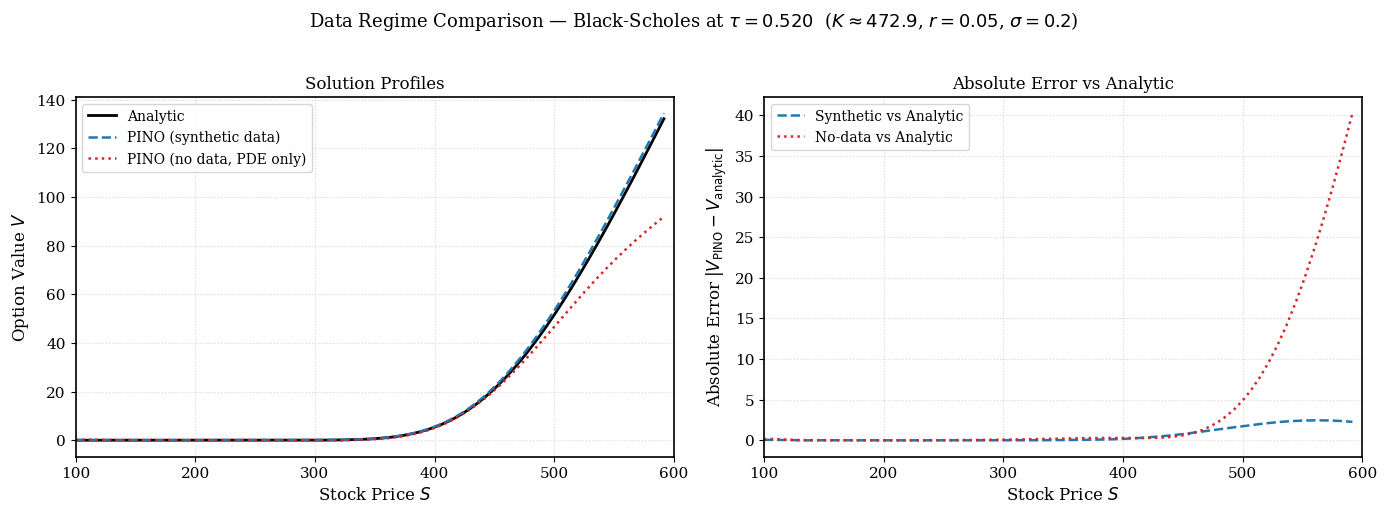

In [31]:
# Run the comparison
 
plot_regime_comparison(
    test_x_syn, test_y_syn, preds_syn,
    test_x_nd,  preds_nd,
    tau_target=0.5,
    key=0,
    S_min=config['data']['S_min'],
    S_max=config['data']['S_max'],
    r=config['data']['r'],
    sigma=config['data']['sigma'],
    T=config['data']['T'],
    save_path='BlackScholes/figures/regime_comparison_tau05.png',
)

In [32]:
# =============================================================================
# Real-World Data Integration — AAPL Options from Yahoo Finance
# =============================================================================
# This block adds a third regime to the no-data / synthetic-data comparison:
# a PINO trained with sparse real market prices as additional supervision.
#
# Pipeline overview
# -----------------
#  1. Fetch live AAPL option chain (Yahoo Finance via yfinance)
#  2. Filter to liquid, near-the-money calls whose spot falls inside [S_min, S_max]
#  3. Train/val split stratified by expiration
#  4. Calibrate one Black-Scholes volatility per expiry (fit on train set)
#  5. Build sparse training tensors: for each unique strike K, create a
#     (Nt × Nx) grid that is zero everywhere except at the (tau, S_spot)
#     grid point where a market price was observed — plus a binary mask
#  6. Train a fresh PINO with IC + PDE + masked-data loss
#  7. Collect predictions and add a "PINO (real-world)" curve to the
#     existing three-way comparison plot at tau = 0.5
# =============================================================================

In [33]:
# ── Cell 1: Imports (add to existing import block if preferred) ───────────────

import sys, os
sys.path.insert(0, '.')          # make sure real_data_validation is importable

from real_data_validation import (
    fetch_aapl_options,
    filter_liquid_calls,
    split_calls_train_val,
    calibrate_sigma_per_expiry,
    sigma_for_T,
    build_sparse_training_set,
    DataLoaderBSSparse,
    train_bs_real,
    build_validation_set,
    evaluate_pino_vs_market,
    plot_validation_results,
    _bs_call_analytical,
)

In [34]:
# ── Cell 2: Fetch and filter AAPL options ────────────────────────────────────
#
# NOTE ON S-GRID COMPATIBILITY
# ----------------------------
# The model was trained with S_min=1, S_max=200.  AAPL's spot is currently
# in the ~$170–220 range.  Values up to ~$200 land cleanly on the existing
# grid; anything above will be skipped by build_sparse_training_set's
# out-of-range guard.  If AAPL has moved significantly above $200 you have
# two options:
#   (a) retrain with S_max=300 (recommended for a proper real-data paper),
#   (b) use filter_liquid_calls with a moneyness_range that clips extreme
#       strikes and accepts only options where spot <= S_max.
# For reproducibility we also cap S_max at config['data']['S_max'] below.

df_raw = fetch_aapl_options(ticker_symbol='AAPL', max_expirations=6)
calls_all = filter_liquid_calls(
    df_raw,
    moneyness_range=(0.80, 1.20),
    min_volume=10,
)

# Hard-clip to S-grid bounds (so build_sparse_training_set doesn't silently
# skip all samples if AAPL is trading above S_max)
S_min_cfg = config['data']['S_min']
S_max_cfg = config['data']['S_max']
calls_all = calls_all[
    (calls_all['spot_price'] >= S_min_cfg) &
    (calls_all['spot_price'] <= S_max_cfg)
].copy()
print(f"After S-grid clip: {len(calls_all)} options remain "
      f"(spot must be in [{S_min_cfg}, {S_max_cfg}])")

if len(calls_all) == 0:
    raise RuntimeError(
        "No options survive the S-grid clip.  AAPL is likely trading above "
        f"S_max={S_max_cfg}.  Either update config['data']['S_max'] and retrain "
        "the synthetic model, or switch to a cheaper underlying (e.g. IWM, SPY)."
    )

Fetched 536 contracts for AAPL (spot=315.20) across 6 expirations
Filtered to 121 liquid near-the-money calls
After S-grid clip: 121 options remain (spot must be in [100.0, 600.0])


In [35]:
# ── Cell 3: Train / val split + per-expiry volatility calibration ─────────────

train_calls, val_calls = split_calls_train_val(
    calls_all, val_frac=0.3, seed=42, stratify_by_expiry=True)

# Calibrate one sigma per expiry on the TRAIN set only.
# This is the "fair" constant-vol benchmark: the same sigma is fed to both the
# analytic BS formula and the PINO, so any residual gap is pure smile / operator error.
r_cfg     = config['data']['r']
sigma_lookup = calibrate_sigma_per_expiry(train_calls, r=r_cfg)

Split 121 calls -> 83 train / 38 validation (val_frac=0.3)
Calibrated per-expiry sigma (fit on train set):
  T=0.0055 yr -> sigma=0.3399
  T=0.0137 yr -> sigma=0.3097
  T=0.0192 yr -> sigma=0.2993
  T=0.0246 yr -> sigma=0.2935
  T=0.0411 yr -> sigma=0.2707


In [36]:
# ── Cell 4: Build sparse training tensors ─────────────────────────────────────

x_real, y_sparse, mask, sigma_data, meta_real = build_sparse_training_set(
    train_calls, config, sigma_lookup=sigma_lookup)

# DataLoaderBSSparse yields (x, y_sparse, mask) triples — drop-in for train_bs_real
dataset_real = DataLoaderBSSparse(
    x_real, y_sparse, mask,
    nx=config['data']['nx'],
    nt=config['data']['nt'],
    sub=config['data']['sub'],
    sub_t=config['data']['sub_t'],
)

n_real   = len(x_real)
n_train_real = max(1, int(0.9 * n_real))   # use 90% of real samples for training
train_loader_real = dataset_real.make_loader(
    n_train_real, config['train']['batchsize'], start=0, train=True)

Built sparse training set: 32 samples (unique strikes)
  Grid size per sample: [26, 128] = 3328 points
  Total observations:   54 / 106496 (0.0507% filled)


In [37]:
n_real_samples = len(x_real)
print(n_real_samples)

32


In [38]:
# After Cell 4 (build_sparse_training_set), add:
n_real_samples = len(x_real)
print(f"Real-world training samples (unique strikes): {n_real_samples}")

# Then when building the synthetic loaders, match it:
train_loader_matched = dataset.make_loader(
    n_real_samples,                      # <-- was config['data']['n_train']
    config['train']['batchsize'],
    start=0, train=True
)
test_loader_matched = dataset.make_loader(
    config['data']['n_test'],
    config['test']['batchsize'],
    start=n_real_samples, train=False    # <-- start after the matched train set
)

Real-world training samples (unique strikes): 32


In [39]:
# ── Cell 5: Instantiate and train the real-data model ────────────────────────

model_real = FNN2d(
    modes1=config['model']['modes1'],
    modes2=config['model']['modes2'],
    fc_dim=config['model']['fc_dim'],
    layers=config['model']['layers'],
    activation=config['model']['activation'],
).to(device)

optimizer_real = Adam(model_real.parameters(), betas=(0.9, 0.999),
                      lr=config['train']['base_lr'])
scheduler_real = torch.optim.lr_scheduler.MultiStepLR(
    optimizer_real,
    milestones=config['train']['milestones'],
    gamma=config['train']['scheduler_gamma'])

train_bs_real(
    model_real,
    train_loader_real,
    optimizer_real,
    scheduler_real,
    config,
    rank=device,
    log=log,
)

Epoch 5, loss: 36112.36719 PDE: 228.68558 data: 141.07221 IC: 6894.59180:   1%|          | 4/500 [00:00<00:27, 18.32it/s]

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_real_0.pt


Epoch 105, loss: 37.31663 PDE: 26.55122 data: 0.20510 IC: 1.74288:  21%|██        | 104/500 [00:03<00:13, 29.33it/s]      

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_real_100.pt


Epoch 206, loss: 13.19180 PDE: 8.66016 data: 0.11831 IC: 0.66971:  41%|████      | 206/500 [00:07<00:09, 29.96it/s] 

...

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_real_300.pt


Epoch 406, loss: 6.96673 PDE: 4.45718 data: 0.07747 IC: 0.34697:  81%|████████  | 405/500 [00:13<00:03, 29.61it/s]

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_real_400.pt


Epoch 499, loss: 6.07302 PDE: 3.73357 data: 0.08799 IC: 0.29191: 100%|██████████| 500/500 [00:16<00:00, 29.76it/s]

Checkpoint is saved at checkpoints/BlackScholes/BlackScholes-eqn_real_final.pt
Done!


Runs evaluate_pino_vs_market on the held-out 30% of real options for all three models — gives you MAE and RMSE vs. market per regime in the notebook output.

In [40]:
# ── Cell 6: Evaluate all three regimes against held-out real prices ────────────
#
# The validation set comes from val_calls (held out above).
# evaluate_pino_vs_market extracts the prediction at the exact (S_spot, tau)
# grid point for each option and compares it to the market mid-price.

val_x, val_meta = build_validation_set(
    val_calls, config, sigma_lookup=sigma_lookup)

print("\n── Synthetic-data PINO vs. real market ──────────────")
results_syn  = evaluate_pino_vs_market(model,       val_x, val_meta, config, device)

print("\n── No-data PINO vs. real market ──────────────────────")
results_nd   = evaluate_pino_vs_market(model_nodata, val_x, val_meta, config, device)

print("\n── Real-data PINO vs. real market ────────────────────")
results_real = evaluate_pino_vs_market(model_real,   val_x, val_meta, config, device)

Built validation set: 38 options, input shape per sample: (26, 128, 3)

── Synthetic-data PINO vs. real market ──────────────

=== Validation Summary (38 options, held-out) ===
PINO   mean abs error vs market: $1.3387
BS     mean abs error vs market: $0.1565
PINO   RMSE vs market:           $1.7174
BS     RMSE vs market:           $0.2053
PINO-vs-BS RMSE (operator fit):  $1.7544  (small => PINO faithfully emulates BS at the calibrated sigma)

── No-data PINO vs. real market ──────────────────────

=== Validation Summary (38 options, held-out) ===
PINO   mean abs error vs market: $1.5090
BS     mean abs error vs market: $0.1565
PINO   RMSE vs market:           $1.8443
BS     RMSE vs market:           $0.2053
PINO-vs-BS RMSE (operator fit):  $1.8704  (small => PINO faithfully emulates BS at the calibrated sigma)

── Real-data PINO vs. real market ────────────────────

=== Validation Summary (38 options, held-out) ===
PINO   mean abs error vs market: $0.5114
BS     mean abs error vs marke

plot_regime_comparison_with_real extends your existing two-model plot to four curves — Analytic (black), Synthetic PINO (blue dashed), No-data PINO (red dotted), Real-world PINO (green dash-dot) — evaluated on the same synthetic test set at τ=0.5 so the comparison is apples-to-apples on V vs S. Saves to BlackScholes/figures/regime_comparison_tau05_with_real.png

In [41]:
# ── Cell 7: Four-way comparison plot at tau = 0.5 ────────────────────────────
#
# Now with four curves: Analytic | Synthetic | No-data | Real-world.
# We still plot V vs S for a single representative K (key=0 by default)
# so the comparison is 1-D and visually matches the rest of the paper.

def plot_regime_comparison_with_real(
        test_x_syn, test_y_syn, preds_syn,
        test_x_nd,  preds_nd,
        test_x_real, preds_real,
        tau_target=0.5,
        key=0,
        S_min=1.0, S_max=200.0,
        r=0.05, sigma=0.2, T=1.0,
        save_path=None):
    """
    V vs S comparison at a fixed tau for all three data regimes + analytic.

    Panels
    ------
    Left  : solution profiles — Analytic, Synthetic PINO, No-data PINO,
            Real-data PINO — at tau = tau_target for sample `key`.
    Right : absolute error vs analytic for each PINO variant.

    Parameters
    ----------
    test_x_syn  / test_x_nd / test_x_real : (Ntest, Nt, Nx, 3)
    test_y_syn                             : (Ntest, Nt, Nx)  CN labels (ground truth)
    preds_syn / preds_nd / preds_real      : (Ntest, Nt, Nx)  model outputs
    """

    # ── Coordinates ──────────────────────────────────────────────────────
    a        = test_x_syn[key]           # (Nt, Nx, 3)
    x_norm   = a[0, :, 1]
    tau_norm = a[:, 0, 2]
    Lx       = math.log(S_max / S_min)
    S        = np.exp(np.log(S_min) + x_norm * Lx)

    tau_phys = tau_norm * T
    tau_idx  = int(np.argmin(np.abs(tau_phys - tau_target)))
    tau_actual = tau_phys[tau_idx]

    # ── Extract slices ────────────────────────────────────────────────────
    slice_syn  = preds_syn[key][tau_idx]
    slice_nd   = preds_nd[key][tau_idx]
    slice_real = preds_real[key][tau_idx]

    # ── Analytic reference (reconstruct K from payoff IC) ─────────────────
    payoff = a[0, :, 0]
    above  = payoff > 0
    K_est  = S[np.argmax(above)] if above.any() else (S_min + S_max) / 2.0

    analytic = np.array([
        _bs_call_analytical(float(s), K_est, r, sigma, tau_actual)
        for s in S
    ], dtype=np.float32)

    # ── Absolute errors vs analytic ───────────────────────────────────────
    err_syn  = np.abs(slice_syn  - analytic)
    err_nd   = np.abs(slice_nd   - analytic)
    err_real = np.abs(slice_real - analytic)

    # ── Figure ────────────────────────────────────────────────────────────
    plt.rcParams.update({'font.family': 'serif', 'font.size': 11,
                         'axes.linewidth': 1.2})

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(
        rf'Data Regime Comparison — Black-Scholes at $\tau = {tau_actual:.3f}$'
        rf'  ($K \approx {K_est:.1f}$, $r={r}$, $\sigma={sigma}$, AAPL options)',
        fontsize=13, y=1.02,
    )

    # Left: solution profiles
    ax1.plot(S, analytic,    color='black',      lw=2.2,        label='Analytic BS')
    ax1.plot(S, slice_syn,   color='tab:blue',   lw=1.8, ls='--', label='PINO (synthetic data)')
    ax1.plot(S, slice_nd,    color='tab:red',    lw=1.8, ls=':',  label='PINO (no data, PDE only)')
    ax1.plot(S, slice_real,  color='tab:green',  lw=1.8, ls='-.', label='PINO (real-world, AAPL)')

    ax1.set_xlabel('Stock Price $S$', fontsize=12)
    ax1.set_ylabel('Option Value $V$', fontsize=12)
    ax1.set_title('Solution Profiles', fontsize=12)
    ax1.set_xlim([S_min, S_max])
    ax1.legend(frameon=True, facecolor='white', fontsize=10)
    ax1.grid(True, linestyle=':', alpha=0.5)

    # Right: absolute error
    ax2.plot(S, err_syn,  color='tab:blue',  lw=1.8, ls='--', label='Synthetic vs Analytic')
    ax2.plot(S, err_nd,   color='tab:red',   lw=1.8, ls=':',  label='No-data vs Analytic')
    ax2.plot(S, err_real, color='tab:green', lw=1.8, ls='-.', label='Real-world vs Analytic')

    ax2.set_xlabel('Stock Price $S$', fontsize=12)
    ax2.set_ylabel(r'Absolute Error $|V_{\mathrm{PINO}} - V_{\mathrm{analytic}}|$',
                   fontsize=12)
    ax2.set_title('Absolute Error vs Analytic', fontsize=12)
    ax2.set_xlim([S_min, S_max])
    ax2.legend(frameon=True, facecolor='white', fontsize=10)
    ax2.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Saved to {save_path}')

    plt.show()

In [42]:
# ── Cell 8: Collect real-data model predictions on the SAME test set ──────────
#
# The real-data model was trained on a different loader (sparse real prices),
# but we evaluate it on the same synthetic test_loader so all three models
# are compared on identical inputs — giving a fair apples-to-apples plot.

Nx_  = config['data']['nx'] // config['data']['sub']
Nt_  = config['data']['nt'] // config['data']['sub_t'] + 1
Ntest = config['data']['n_test']

test_x_real, test_y_real, preds_real = collect_preds(
    model_real, test_loader, device, Ntest, Nt_, Nx_)

Saved to BlackScholes/figures/regime_comparison_tau05_with_real.png


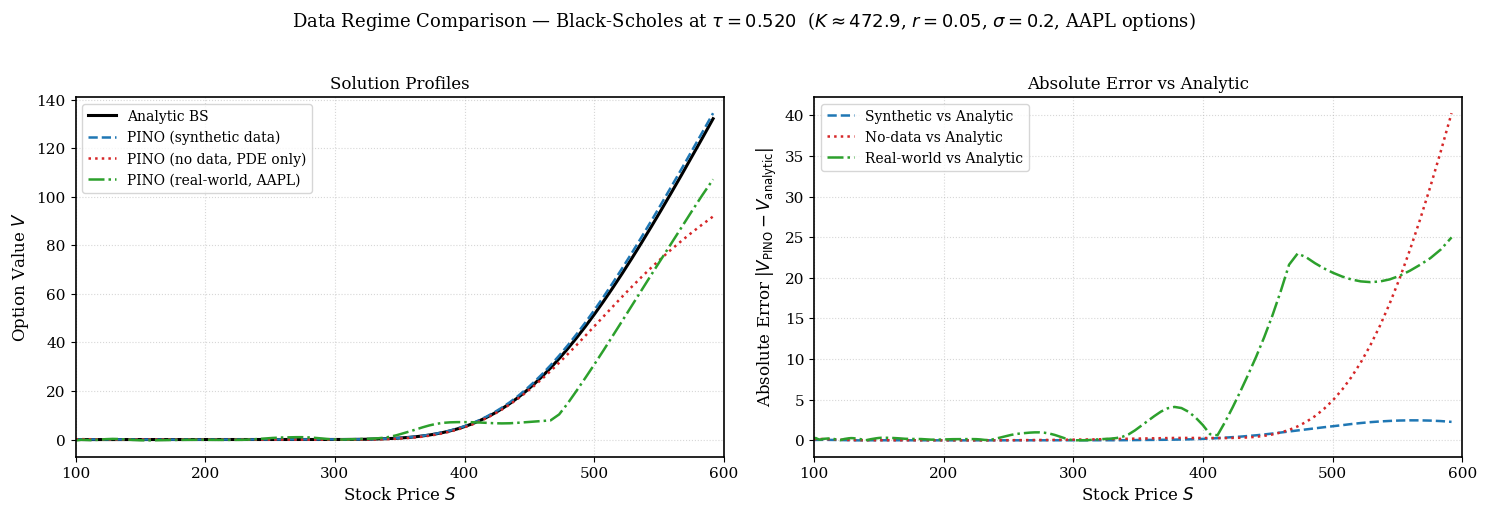

In [45]:
# ── Cell 9: Produce the final four-way plot ───────────────────────────────────

plot_regime_comparison_with_real(
    test_x_syn, test_y_syn, preds_syn,    # from previous experiment cell
    test_x_nd,  preds_nd,                 # from previous experiment cell
    test_x_real, preds_real,              # new real-data model
    tau_target=0.5,
    key=0,
    S_min=config['data']['S_min'],
    S_max=config['data']['S_max'],
    r=config['data']['r'],
    sigma=config['data']['sigma'],
    T=config['data']['T'],
    save_path='BlackScholes/figures/regime_comparison_tau05_with_real.png',
)

Saved to BlackScholes/figures/real_data_validation.png


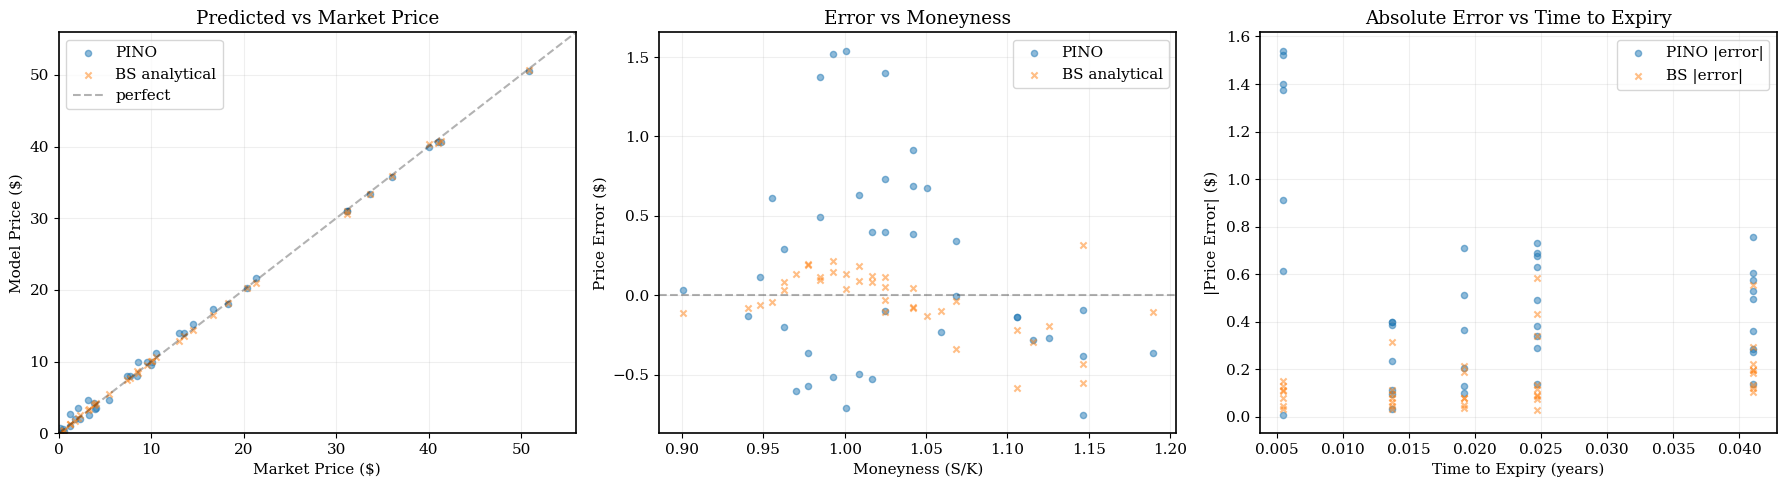

In [46]:
# Optional: the partner's diagnostic plots (scatter, moneyness, vol smile)
plot_validation_results(results_real,
                        save_dir='BlackScholes/figures/')